# Criminal Activity
The dataset of Monthly Criminal Activity contains data about police reports. Each row in the dataset includes the date, neighborhood, and type of crime, among many other statistics. We will analyze this dataset to see which neighborhoods have the highest crime rates. 

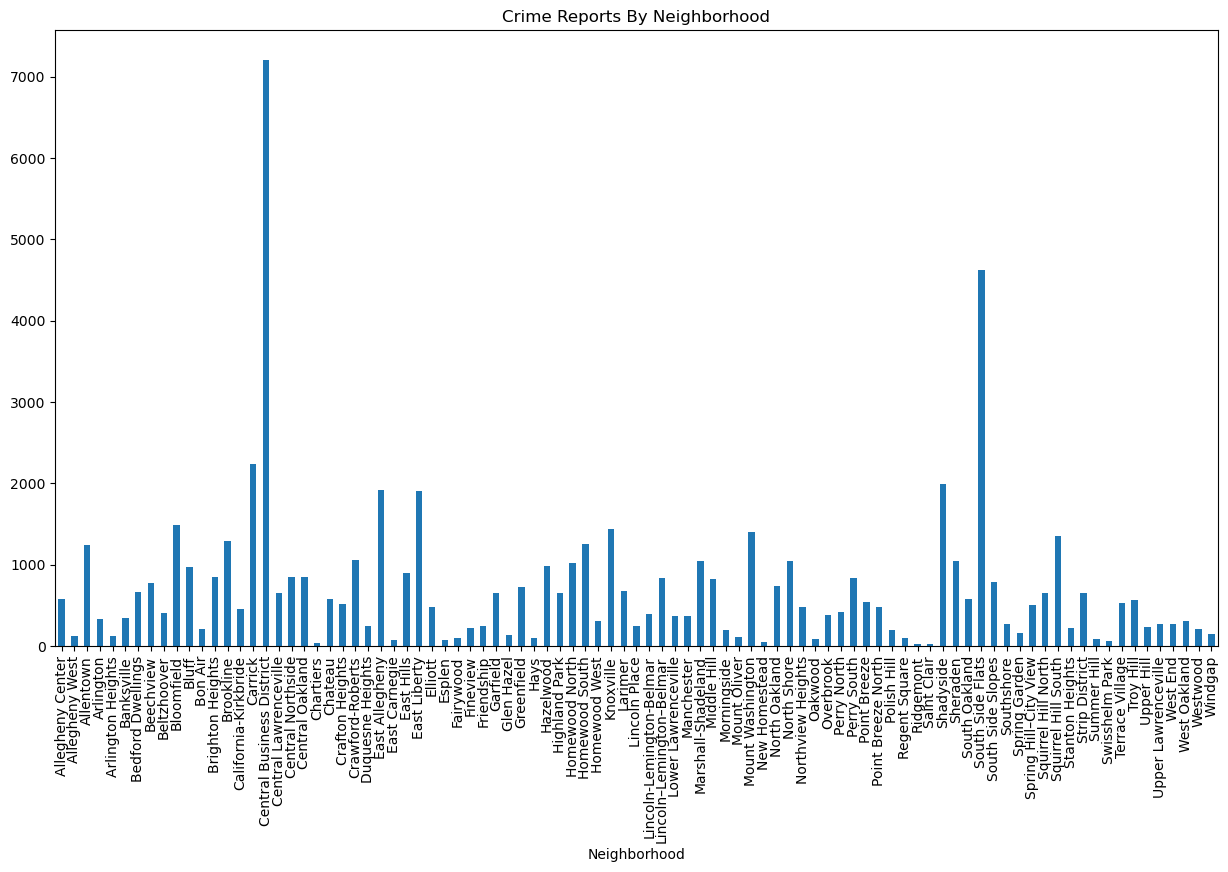

In [13]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

crime = pd.read_csv("crime.csv", low_memory=False)
#crime.pivot(columns="Neighborhood", values="NIBRS_Offense_Category")

crime.groupby("Neighborhood").count()["NIBRS_Offense_Category"].plot(title="Crime Reports By Neighborhood",kind="bar", figsize=(15,8))
plt.show()
#.count().plot(kind="bar", figsize=(10,10))
# crime.plot(x="Neighborhood", kind="bar", figsize=(10,10))
# plt.show()

This graph looks a little odd, but it shows the overall number of reports by neighborhood. Here, the leaders are the Central Business District and South Side Flats. It's hard to tell which neighborhoods have the least, though, so let's get a count:

In [14]:
sorted_crime = crime.groupby("Neighborhood").count()["NIBRS_Offense_Category"].sort_values()
sorted_crime

Neighborhood
Saint Clair                    25
Ridgemont                      33
Chartiers                      38
New Homestead                  54
Swisshelm Park                 66
                             ... 
East Allegheny               1915
Shadyside                    1992
Carrick                      2241
South Side Flats             4622
Central Business District    7209
Name: NIBRS_Offense_Category, Length: 91, dtype: int64

That's better. Now, we can see that from the raw data alone, Saint Clair has the fewest crime reports, followed by Ridgemont and Chartiers.

In [3]:
#creating an array of all the neighborhood names
neighborhoods = crime.pivot(columns="Neighborhood").columns
new_neighborhoods = []
for i in range(len(neighborhoods[1:])):
    if '_id' in neighborhoods[i]:
        new_neighborhoods.append(neighborhoods[i][1])
neighborhoods = new_neighborhoods[1:]

In [4]:
# num = sorted_crime["Saint Clair"]
# crime.pivot(columns="Neighborhood", values="NIBRS_Offense_Category")["Saint Clair"].sort_values().head(num)

But, some crimes are way worse than others, and way more indicative of safety. Let's see if we can look at the categories of crime and sort by that.

In [5]:
# saint_clair = crime.pivot(columns="Neighborhood", values="NIBRS_Offense_Category")["Saint Clair"]
# sc_crimes_dict = {}
# for index in saint_clair:
#     if str(index) != "nan":
#         if str(index) not in sc_crimes_dict:
#             sc_crimes_dict[str(index)] = 1
#         else:
#             sc_crimes_dict[str(index)] += 1
sc_crimes_dict = {}
specific_dict = {}
for i in neighborhoods:
    num = sorted_crime[i]
    newdict = {}
    saint_clair = crime.pivot(columns="Neighborhood", values="NIBRS_Offense_Category")[i]
    for index in saint_clair:
        if str(index) != "nan":
            if str(index) not in sc_crimes_dict:
                sc_crimes_dict[str(index)] = 1
            else:
                sc_crimes_dict[str(index)] += 1
            if str(index) not in newdict:
                newdict[str(index)] = 1
            else:
                newdict[str(index)] += 1
    specific_dict[i] = newdict
specific_dict #categorizes every neighborhood by type of crime
sc_crimes_dict #shows all types of crime

{'Larceny/Theft Offenses': 11404,
 'Drug/Narcotic Offenses': 5905,
 'Not NIBRS Reportable': 11769,
 'Destruction/Damage/Vandalism of Property': 5098,
 'Weapon Law Violations': 1345,
 'All other Offenses': 10245,
 'Assault Offenses': 10987,
 'Motor Vehicle Theft': 2035,
 'Fraud Offenses': 3358,
 'Burglary/Breaking & Entering': 1482,
 'Robbery': 790,
 'Kidnapping/Abduction': 145,
 'Arson': 208,
 'Human Trafficking': 7,
 'Homicide Offenses': 71}

Those are all the categories of crime. Let's see how many violent crimes took place in each neighborhood:

In [6]:
maxnum = 0
vc = {}
violent_crimes_list = ["Homicide Offenses", "Human Trafficking", "Arson", "Kidnapping/Abduction", "Assault Offenses", "Robbery", "Motor Vehicle Theft", "Larceny/Theft Offenses"]
for j in violent_crimes_list:
    vc[j] = {}
    for i in neighborhoods:
        if j in specific_dict[i]:
            vc[j][i] = specific_dict[i][j]
        else:
            vc[j][i] = 0
violent_crimes = pd.DataFrame(vc)
violent_crimes.iloc[60:70, :]


,Homicide Offenses,Human Trafficking,Arson,Kidnapping/Abduction,Assault Offenses,Robbery,Motor Vehicle Theft,Larceny/Theft Offenses
Overbrook,2,0,1,0,56,1,26,72
Perry North,1,0,4,2,114,4,20,54
Perry South,2,0,2,2,210,7,34,87
Point Breeze,0,0,2,0,38,5,16,167
Point Breeze North,0,0,0,1,63,7,20,111
Polish Hill,0,0,0,0,23,1,17,26
Regent Square,0,0,0,1,4,0,4,17
Ridgemont,0,0,0,0,3,0,0,5
Saint Clair,0,0,0,0,7,0,2,4
Shadyside,1,0,5,0,198,10,60,878


Look at the nice dataframe!!! Let's see a graph of all the violent crimes by neighborhood. 

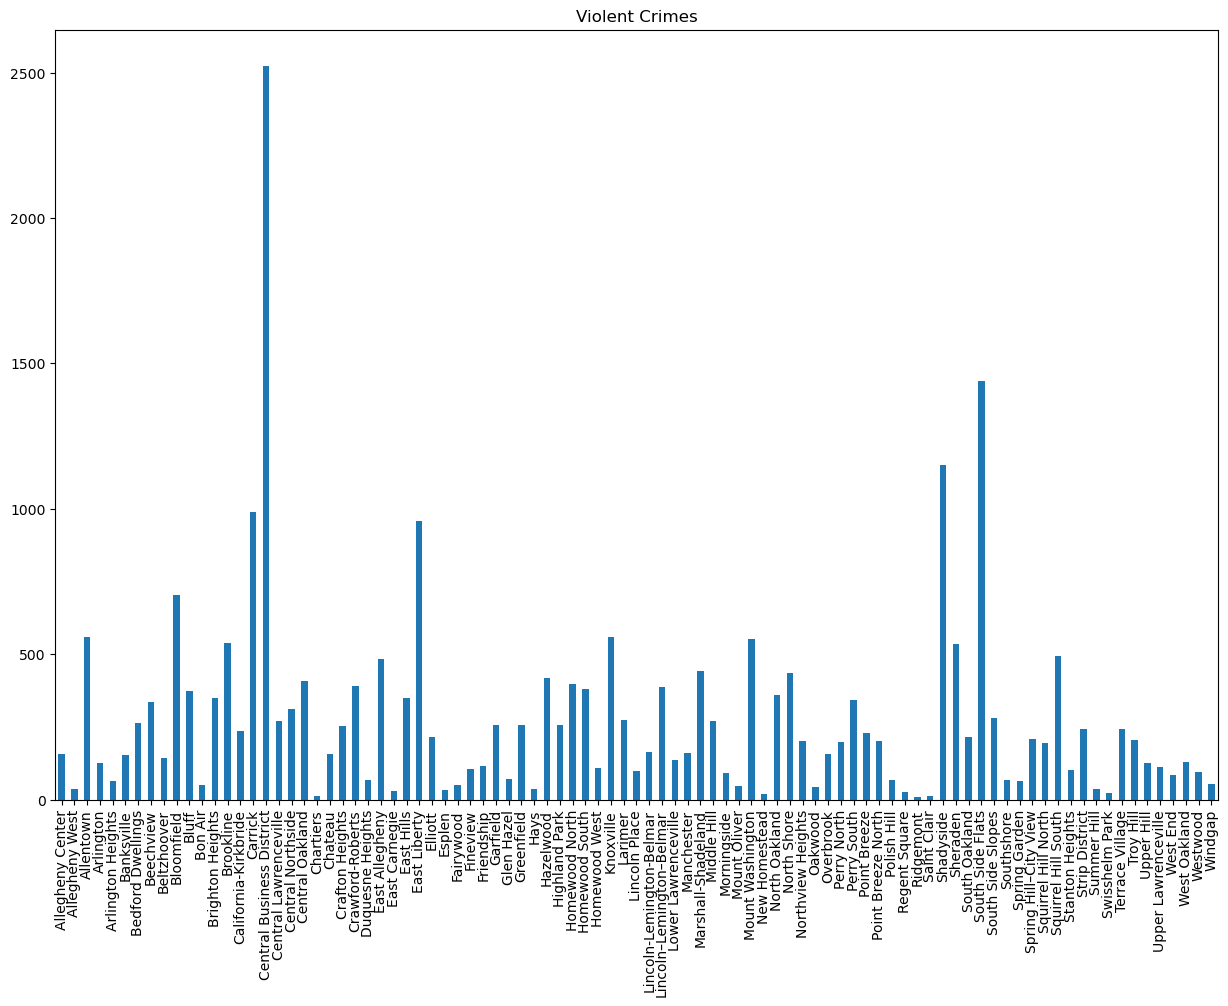

In [9]:
newdf = 0
for i in violent_crimes_list:
    newdf = newdf + violent_crimes[i]
newdf.plot(title="Violent Crimes", subplots=False,kind="bar",legend=False, figsize=(15, 10))
plt.show()

It looks ... pretty much the same as the first one. Big whoop.

In [16]:
sorted_newdf = newdf.sort_values()
sorted_newdf

Ridgemont                       8
Saint Clair                    13
Chartiers                      14
New Homestead                  19
Swisshelm Park                 22
                             ... 
East Liberty                  960
Carrick                       991
Shadyside                    1152
South Side Flats             1440
Central Business District    2521
Length: 91, dtype: int64

But, if we look at the sorted list, we see that Ridgemont is actually the safest neighborhood in terms of violent crime, followed by Saint Clair and Chartiers. Nice!

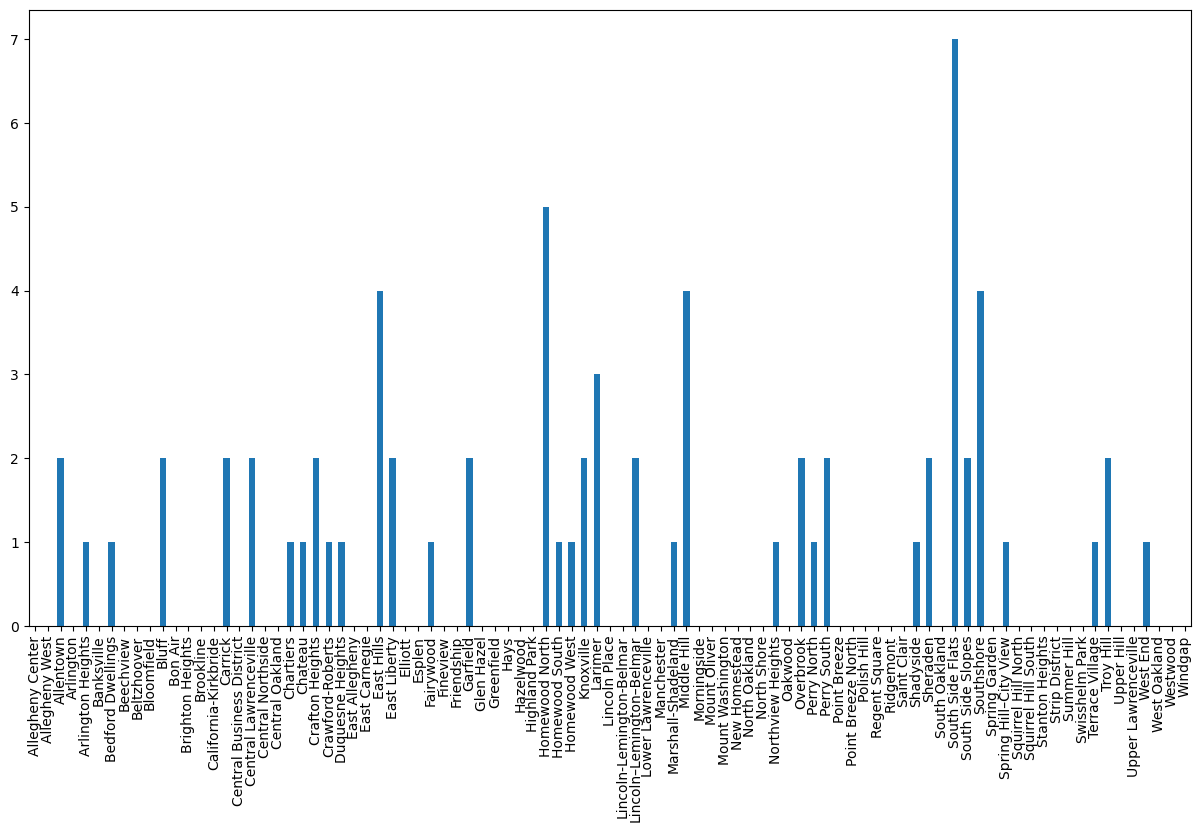

In [12]:
violent_crimes["Homicide Offenses"].plot(kind="bar", figsize=(15,8))
plt.show()

# Conclusion
In the end, I concluded that Ridgemont was the safest neighborhood because it has the lowest amount of violent crime. In terms of all crime, Saint Clair is the safest, but I feel like violent crime is what more people are worried about than nonviolent crime, so it would be safer for a person to be in a neighborhood with less violent crime even if there are technically more illegal offenses overall. I don't know whether this result is surprising since I'm not from Pittsburgh and I've never been to Ridgemont, but I noticed that South Side has really high crime rates, and I have heard a lot from friends about the area so I'm not surprised. I visited South Side once and it was fine, but that's neither here nor there. 